# **Evolução do Desemprego no Brasil (2015–2024)**
**Projeto G2 – Tema 4 | Python · Pandas · Matplotlib · Seaborn**

## 1. Introdução
O desemprego é um dos principais termômetros socioeconômicos de um país: afeta renda familiar, consumo, qualidade de vida e o desenvolvimento regional. Este notebook investiga a **evolução da taxa de desemprego no Brasil entre 2015 e 2024**, usando um dataset simulado com 20 estados.

**Perguntas que o trabalho busca responder**
1. Quais regiões e estados têm maior e menor desemprego?
2. Existem períodos de crise evidentes? O desemprego subiu ou caiu no período?
3. Há diferenças relevantes entre regiões?
4. Há sazonalidade por trimestre ou setor?
5. Qual a relação entre inflação, renda e desemprego?
6. Quais grupos (estados/regiões) são mais vulneráveis?

## 2. Contextualização econômica
- **2015–2016:** recessão brasileira (queda do PIB, alta de juros e inflação), com forte destruição de empregos formais.
- **2017–2019:** recuperação lenta e gradual.
- **2020–2021:** pandemia de COVID-19, com paralisações e queda da ocupação.
- **2022–2024:** retomada da atividade e redução do desemprego.
- **Desigualdade regional:** Norte e Nordeste historicamente apresentam menor formalização e maior desocupação que Sul e Centro-Oeste.

> ⚠️ Os dados são **simulados**: servem para exercitar a análise, e os resultados não devem ser lidos como estatística oficial (IBGE/PNAD).

## 3. Explicação da base de dados
`simulacao_desemprego_brasil.csv`: **800 linhas** = 20 UFs × 10 anos × 4 trimestres.

| Coluna | Descrição |
|---|---|
| ano, trimestre, data | Período de referência |
| regiao, uf | Localização (5 regiões, 20 estados) |
| populacao_ativa | População economicamente ativa (PEA) |
| empregados / desempregados | Pessoas ocupadas / desocupadas (soma = PEA) |
| taxa_desemprego | Percentual de desemprego |
| renda_media | Renda média mensal (R$) |
| setor_predominante | Principal setor econômico no período |
| vagas_formais | Novas vagas formais |
| inflacao | Inflação (%) |
| nivel_risco | Baixo, Médio, Alto, Crítico |

## 4. Configuração e leitura dos dados

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Procura o CSV nas pastas mais comuns (Colab, GitHub, notebooks/)
CAMINHOS = ['simulacao_desemprego_brasil.csv',
            'dados/simulacao_desemprego_brasil.csv',
            '../dados/simulacao_desemprego_brasil.csv']
file_path = next((p for p in CAMINHOS if os.path.exists(p)), None)

if file_path is None:
    # No Colab: abre o seletor de upload
    from google.colab import files
    files.upload()
    file_path = 'simulacao_desemprego_brasil.csv'

df = pd.read_csv(file_path)
print(f"Arquivo: {file_path} | {df.shape[0]} linhas x {df.shape[1]} colunas")
display(df.head())
df.info()

Arquivo: ../dados/simulacao_desemprego_brasil.csv | 800 linhas x 14 colunas
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ano                 800 non-null    int64  
 1   trimestre           800 non-null    int64  
 2   data                800 non-null    str    
 3   regiao              800 non-null    str    
 4   uf                  800 non-null    str    
 5   populacao_ativa     800 non-null    int64  
 6   empregados          800 non-null    int64  
 7   desempregados       800 non-null    int64  
 8   taxa_desemprego     800 non-null    float64
 9   renda_media         800 non-null    float64
 10  setor_predominante  800 non-null    str    
 11  vagas_formais       800 non-null    int64  
 12  inflacao            800 non-null    float64
 13  nivel_risco         800 non-null    str    
dtypes: float64(3), int64(6), str(5)
memory us

,ano,trimestre,data,regiao,uf,populacao_ativa,empregados,desempregados,taxa_desemprego,renda_media,setor_predominante,vagas_formais,inflacao,nivel_risco
0,2015,1,2015-03-01,Norte,AM,1428772,1293887,134885,9.44,2539.67,Construção,9513,7.09,Médio
1,2015,1,2015-03-01,Norte,PA,4912808,4231410,681398,13.87,2536.28,Construção,3104,6.84,Alto
2,2015,1,2015-03-01,Norte,RO,3654834,3217078,437756,11.98,3185.87,Construção,57505,5.48,Alto
3,2015,1,2015-03-01,Norte,TO,3481897,3010863,471034,13.53,1933.31,Comércio,61208,6.76,Alto
4,2015,1,2015-03-01,Nordeste,BA,509015,425557,83458,16.40,3792.59,Serviços,47983,5.51,Crítico


## 5. Limpeza e preparação
Antes de analisar, validamos a **qualidade e a consistência** da base: tipos, nulos, duplicados, coerência entre colunas e outliers.

In [2]:
# 5.1 Tipos e categorias
df['data'] = pd.to_datetime(df['data'])
df['nivel_risco'] = pd.Categorical(df['nivel_risco'],
                                   categories=['Baixo', 'Médio', 'Alto', 'Crítico'], ordered=True)

# 5.2 Nulos e duplicados
print(f"Valores nulos:     {df.isnull().sum().sum()}")
print(f"Linhas duplicadas: {df.duplicated().sum()}")
print(f"Painel completo (20 UFs x 40 trimestres)? {df.groupby('uf').size().eq(40).all()}")

# 5.3 Consistência entre colunas
soma_ok = (df['empregados'] + df['desempregados'] == df['populacao_ativa']).all()
taxa_calc = df['desempregados'] / df['populacao_ativa'] * 100
dif_max = (taxa_calc - df['taxa_desemprego']).abs().max()
print(f"empregados + desempregados == populacao_ativa? {soma_ok}")
print(f"Maior diferença taxa informada x calculada: {dif_max:.4f} p.p. (arredondamento)")

# 5.4 Outliers (regra do IQR) nas variáveis numéricas
for col in ['taxa_desemprego', 'renda_media', 'inflacao', 'vagas_formais']:
    q1, q3 = df[col].quantile([.25, .75])
    lim_i, lim_s = q1 - 1.5*(q3-q1), q3 + 1.5*(q3-q1)
    n = ((df[col] < lim_i) | (df[col] > lim_s)).sum()
    print(f"{col:16s} outliers: {n:3d}  (faixa normal {lim_i:,.2f} a {lim_s:,.2f})")

print(f"\nInflação negativa em {(df['inflacao'] < 0).sum()} registro(s) – mantido (possível em simulação/deflação pontual).")
display(df.describe().round(2))

Valores nulos:     0
Linhas duplicadas: 0
Painel completo (20 UFs x 40 trimestres)? True
empregados + desempregados == populacao_ativa? True
Maior diferença taxa informada x calculada: 0.0051 p.p. (arredondamento)
taxa_desemprego  outliers:   1  (faixa normal 0.50 a 19.33)
renda_media      outliers:   4  (faixa normal 1,225.45 a 4,347.40)
inflacao         outliers:   9  (faixa normal 0.73 a 9.23)
vagas_formais    outliers:   0  (faixa normal -45,054.75 a 133,945.25)

Inflação negativa em 2 registro(s) – mantido (possível em simulação/deflação pontual).


,ano,trimestre,data,populacao_ativa,empregados,desempregados,taxa_desemprego,renda_media,vagas_formais,inflacao
count,800.00,800.00,800,800.00,800.00,800.00,800.00,800.00,800.00,800.00
mean,2019.50,2.50,2020-01-15 18:00:00,3217270.64,2899966.74,317303.90,9.90,2790.65,44820.77,4.98
min,2015.00,1.00,2015-03-01 00:00:00,318431.00,275629.00,15257.00,3.00,1002.32,1063.00,-1.06
25%,2017.00,1.75,2017-08-09 00:00:00,1756632.25,1583077.50,153360.75,7.56,2396.18,22070.25,3.92
50%,2019.50,2.50,2020-01-15 12:00:00,3332223.00,2999189.00,296823.00,9.82,2815.16,44946.50,4.96
75%,2022.00,3.25,2022-06-24 00:00:00,4644644.00,4163297.25,451212.00,12.26,3176.67,66820.25,6.04
max,2024.00,4.00,2024-12-01 00:00:00,5999399.00,5665164.00,923101.00,20.53,4691.42,89691.00,9.90
std,2.87,1.12,NaN,1650285.63,1492184.44,198400.48,3.23,581.40,25624.24,1.58


**Conclusão da limpeza:** a base está íntegra (sem nulos, sem duplicados, painel balanceado e `empregados + desempregados = população ativa`). Há apenas 1 outlier em `taxa_desemprego` (PB, 2023-T3, 20,53%), além de 4 em renda e 9 em inflação, todos pontuais e dentro de faixas plausíveis. **Foram mantidos**, pois não há indício de erro de digitação e removê-los distorceria a análise.

## 6. Engenharia de atributos

In [3]:
df = df.sort_values(['ano', 'trimestre', 'uf']).reset_index(drop=True)

# Rótulo de período e eixo temporal
df['periodo'] = df['ano'].astype(str) + ' - T' + df['trimestre'].astype(str)

# Taxa recalculada a partir dos valores absolutos (mais precisa que a arredondada)
df['taxa_calculada'] = df['desempregados'] / df['populacao_ativa'] * 100

# Vagas formais por 1.000 pessoas da PEA (permite comparar estados de tamanhos diferentes)
df['vagas_por_mil'] = df['vagas_formais'] / df['populacao_ativa'] * 1000

# Variação da taxa em relação ao mesmo trimestre do ano anterior, por UF (remove sazonalidade)
df['var_yoy_pp'] = df.groupby('uf')['taxa_desemprego'].diff(4)

# Classificação do período
def fase(ano):
    if ano <= 2016:   return 'Recessão 2015-16'
    if ano <= 2019:   return 'Recuperação 2017-19'
    if ano <= 2021:   return 'Pandemia 2020-21'
    return 'Retomada 2022-24'
df['fase_economica'] = df['ano'].apply(fase)

display(df[['periodo', 'uf', 'taxa_desemprego', 'taxa_calculada', 'vagas_por_mil', 'var_yoy_pp', 'fase_economica']].head(8))

,periodo,uf,taxa_desemprego,taxa_calculada,vagas_por_mil,var_yoy_pp,fase_economica
0,2015 - T1,AM,9.44,9.440625,6.658165,NaN,Recessão 2015-16
1,2015 - T1,BA,16.40,16.395980,94.266377,NaN,Recessão 2015-16
2,2015 - T1,CE,14.89,14.887928,21.037163,NaN,Recessão 2015-16
3,2015 - T1,DF,7.74,7.740232,11.442299,NaN,Recessão 2015-16
4,2015 - T1,ES,11.42,11.420230,13.990957,NaN,Recessão 2015-16
5,2015 - T1,GO,7.68,7.676580,2.255681,NaN,Recessão 2015-16
6,2015 - T1,MA,13.41,13.408501,13.423025,NaN,Recessão 2015-16
7,2015 - T1,MG,7.89,7.892242,11.994277,NaN,Recessão 2015-16


## 7. KPIs
Dois cuidados metodológicos em relação à versão simples:
- **Taxa média ponderada:** a média simples trata AM (pequeno) e SP (grande) com o mesmo peso. A taxa ponderada (`soma de desempregados / soma da PEA`) reflete melhor o país.
- **Total de desempregados:** como cada linha é um *estoque* trimestral, somar os 40 trimestres conta as mesmas pessoas várias vezes. Por isso apresentamos o **último trimestre** e a **média por trimestre**, além do acumulado pedido no enunciado.

In [4]:
taxa_media = df['taxa_desemprego'].mean()
taxa_pond  = df['desempregados'].sum() / df['populacao_ativa'].sum() * 100

tot_acumulado = df['desempregados'].sum()
tot_ultimo_tri = df[(df['ano'] == 2024) & (df['trimestre'] == 4)]['desempregados'].sum()
media_por_tri = df.groupby(['ano', 'trimestre'])['desempregados'].sum().mean()
renda_media_nac = df['renda_media'].mean()

uf_ranking = df.groupby('uf')['taxa_desemprego'].mean().sort_values(ascending=False)
reg_ranking = df.groupby('regiao')['taxa_desemprego'].mean().sort_values(ascending=False)

anual = df.groupby('ano')['taxa_desemprego'].mean()
var_total = anual.loc[2024] - anual.loc[2015]
ano_pico, ano_vale = anual.idxmax(), anual.idxmin()

print("=" * 62)
print("                     KPIs PRINCIPAIS")
print("=" * 62)
print(f"📌 Taxa média de desemprego (simples):   {taxa_media:.2f}%")
print(f"📌 Taxa média de desemprego (ponderada): {taxa_pond:.2f}%")
print(f"📌 Estado com maior desemprego:          {uf_ranking.index[0]} ({uf_ranking.iloc[0]:.2f}%)")
print(f"📌 Estado com menor desemprego:          {uf_ranking.index[-1]} ({uf_ranking.iloc[-1]:.2f}%)")
print(f"📌 Região mais afetada:                  {reg_ranking.index[0]} ({reg_ranking.iloc[0]:.2f}%)")
print(f"📌 Total acumulado de desempregados:     {tot_acumulado:,}  (soma dos 40 trimestres)")
print(f"📌 Desempregados no último trimestre:    {tot_ultimo_tri:,}  (2024-T4)")
print(f"📌 Média de desempregados por trimestre: {media_por_tri:,.0f}")
print(f"📌 Renda média mensal nacional:          R$ {renda_media_nac:,.2f}")
print(f"📌 Evolução 2015 → 2024:                 {anual.loc[2015]:.2f}% → {anual.loc[2024]:.2f}% ({var_total:+.2f} p.p.)")
print(f"📌 Pior ano: {ano_pico} ({anual.max():.2f}%) | Melhor ano: {ano_vale} ({anual.min():.2f}%)")
print("=" * 62)

                     KPIs PRINCIPAIS
📌 Taxa média de desemprego (simples):   9.90%
📌 Taxa média de desemprego (ponderada): 9.86%
📌 Estado com maior desemprego:          CE (13.65%)
📌 Estado com menor desemprego:          PR (6.71%)
📌 Região mais afetada:                  Nordeste (13.28%)
📌 Total acumulado de desempregados:     253,843,120  (soma dos 40 trimestres)
📌 Desempregados no último trimestre:    5,367,971  (2024-T4)
📌 Média de desempregados por trimestre: 6,346,078
📌 Renda média mensal nacional:          R$ 2,790.65
📌 Evolução 2015 → 2024:                 9.97% → 8.43% (-1.54 p.p.)
📌 Pior ano: 2021 (11.45%) | Melhor ano: 2024 (8.43%)


## 8. Visualizações

### 8.1 Linha temporal – evolução do desemprego

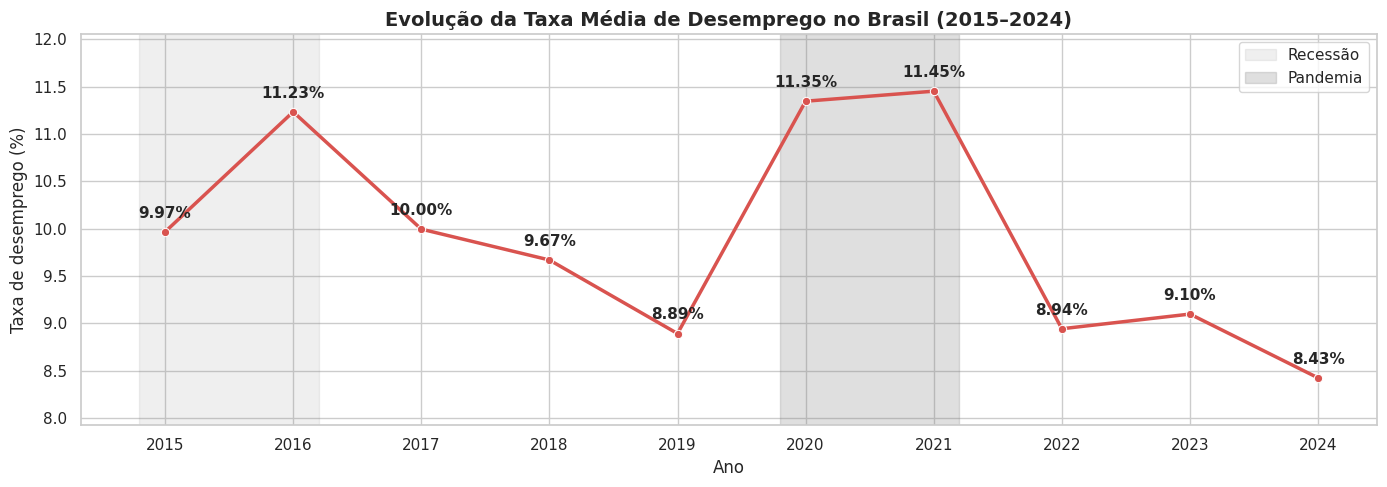

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ev = df.groupby('ano')['taxa_desemprego'].mean().reset_index()
sns.lineplot(data=ev, x='ano', y='taxa_desemprego', marker='o', linewidth=2.5, color='#d9534f', ax=ax)
ax.axvspan(2014.8, 2016.2, color='gray', alpha=.12, label='Recessão')
ax.axvspan(2019.8, 2021.2, color='gray', alpha=.25, label='Pandemia')
for x, y in zip(ev['ano'], ev['taxa_desemprego']):
    ax.text(x, y + 0.15, f'{y:.2f}%', ha='center', fontweight='bold')
ax.set_title('Evolução da Taxa Média de Desemprego no Brasil (2015–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano'); ax.set_ylabel('Taxa de desemprego (%)'); ax.set_xticks(ev['ano']); ax.legend()
ax.set_ylim(ev['taxa_desemprego'].min() - 0.5, ev['taxa_desemprego'].max() + 0.6)
plt.tight_layout(); plt.show()

### 8.2 Evolução trimestral (série completa)

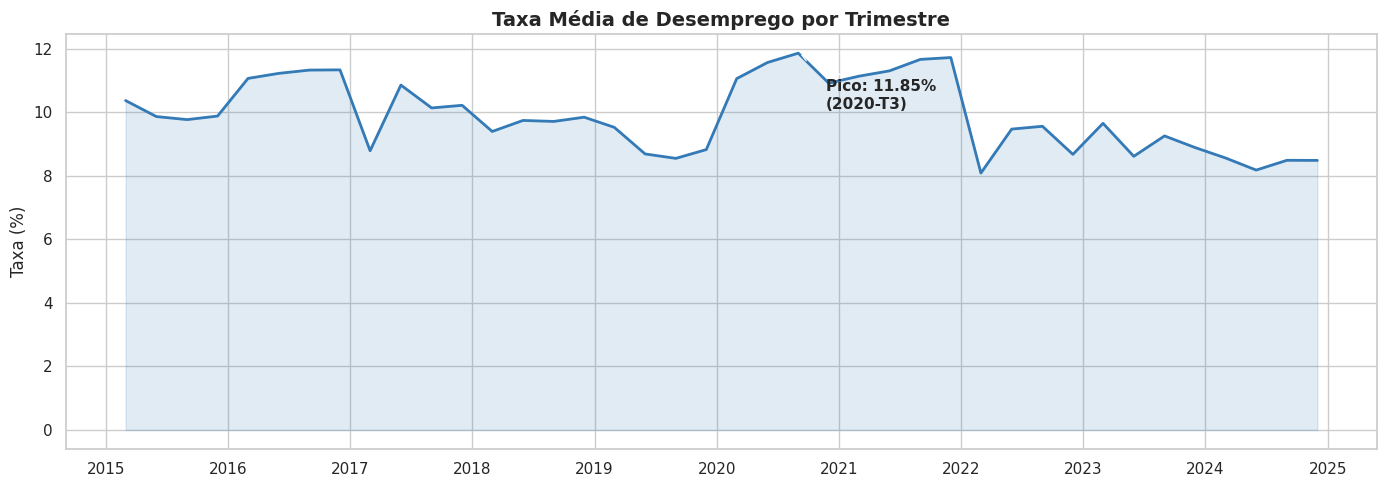

In [6]:
tri = df.groupby(['data', 'ano', 'trimestre'])['taxa_desemprego'].mean().reset_index()
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tri['data'], tri['taxa_desemprego'], color='#337ab7', linewidth=2)
ax.fill_between(tri['data'], tri['taxa_desemprego'], alpha=.15, color='#337ab7')
pico = tri.loc[tri['taxa_desemprego'].idxmax()]
ax.annotate(f"Pico: {pico['taxa_desemprego']:.2f}%\n({int(pico['ano'])}-T{int(pico['trimestre'])})",
            (pico['data'], pico['taxa_desemprego']), xytext=(20, -40), textcoords='offset points',
            arrowprops=dict(arrowstyle='->'), fontweight='bold')
ax.set_title('Taxa Média de Desemprego por Trimestre', fontsize=14, fontweight='bold')
ax.set_ylabel('Taxa (%)'); plt.tight_layout(); plt.show()

### 8.3 Evolução por região

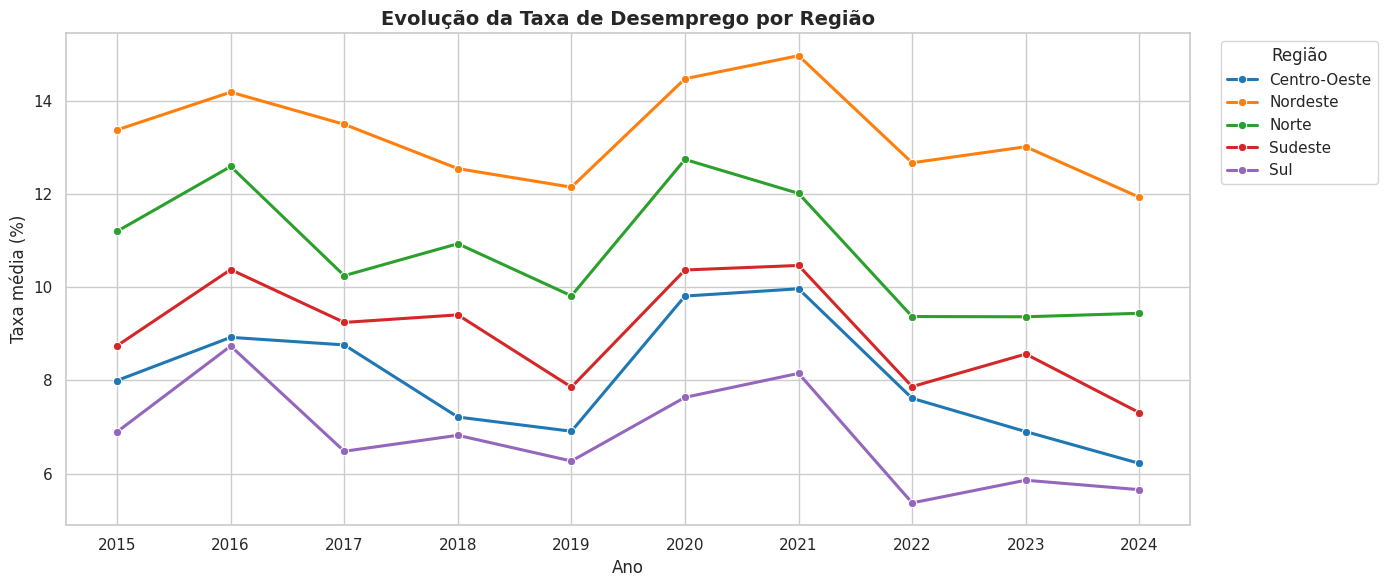

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
reg_ano = df.groupby(['ano', 'regiao'])['taxa_desemprego'].mean().reset_index()
sns.lineplot(data=reg_ano, x='ano', y='taxa_desemprego', hue='regiao', marker='o', linewidth=2.2,
             palette='tab10', ax=ax)
ax.set_title('Evolução da Taxa de Desemprego por Região', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano'); ax.set_ylabel('Taxa média (%)'); ax.set_xticks(range(2015, 2025))
ax.legend(title='Região', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

### 8.4 Barras por região

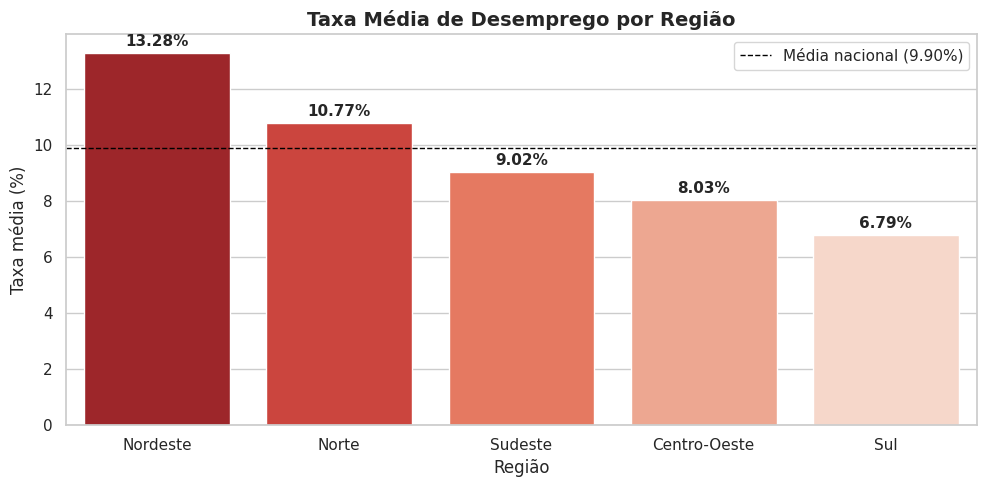

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
reg_df = df.groupby('regiao')['taxa_desemprego'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=reg_df, x='regiao', y='taxa_desemprego', hue='regiao', palette='Reds_r', legend=False, ax=ax)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f%%', padding=3, fontweight='bold')
ax.axhline(taxa_media, color='black', ls='--', lw=1, label=f'Média nacional ({taxa_media:.2f}%)')
ax.set_title('Taxa Média de Desemprego por Região', fontsize=14, fontweight='bold')
ax.set_xlabel('Região'); ax.set_ylabel('Taxa média (%)'); ax.legend()
plt.tight_layout(); plt.show()

### 8.5 Barras por estado (ranking)

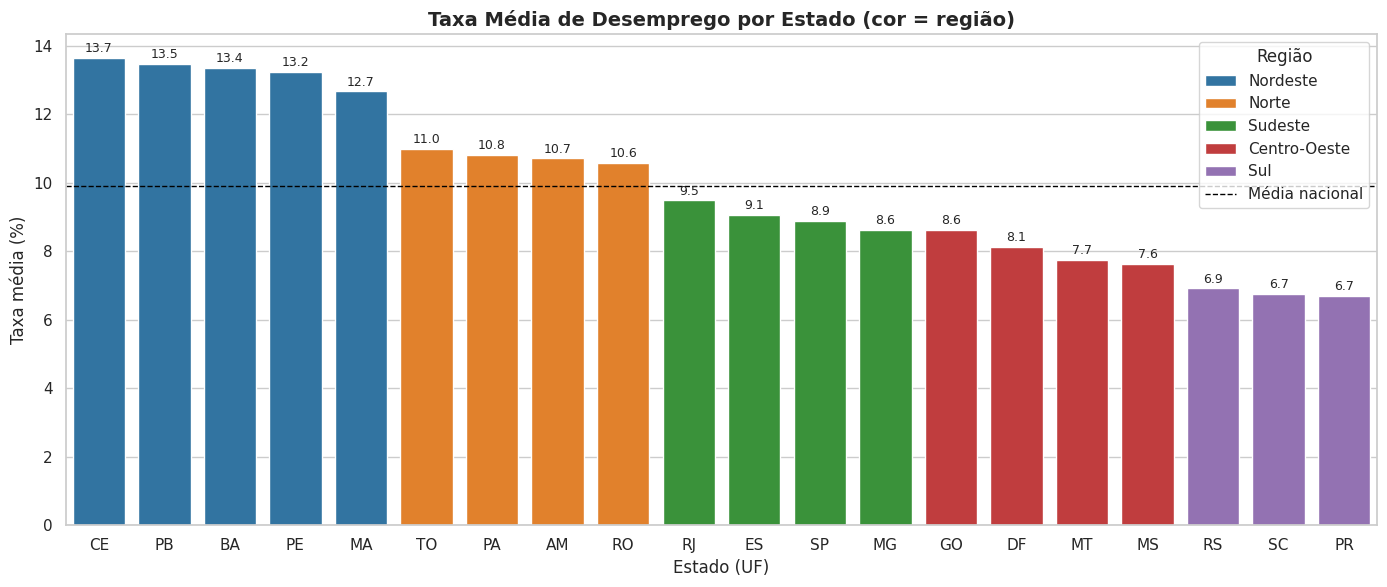

In [9]:
uf_df = df.groupby(['uf', 'regiao'])['taxa_desemprego'].mean().sort_values(ascending=False).reset_index()
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=uf_df, x='uf', y='taxa_desemprego', hue='regiao', dodge=False, palette='tab10', ax=ax)
ax.axhline(taxa_media, color='black', ls='--', lw=1, label='Média nacional')
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f', padding=2, fontsize=9)
ax.set_title('Taxa Média de Desemprego por Estado (cor = região)', fontsize=14, fontweight='bold')
ax.set_xlabel('Estado (UF)'); ax.set_ylabel('Taxa média (%)'); ax.legend(title='Região')
plt.tight_layout(); plt.show()

### 8.6 Ranking de estados críticos

,taxa_media,trimestres_criticos,pct_criticos
uf,,,
CE,13.65,18,45.0
PB,13.47,16,40.0
BA,13.35,20,50.0
PE,13.24,11,27.5
MA,12.67,9,22.5
TO,10.98,6,15.0
PA,10.80,4,10.0
AM,10.71,3,7.5
RO,10.58,3,7.5


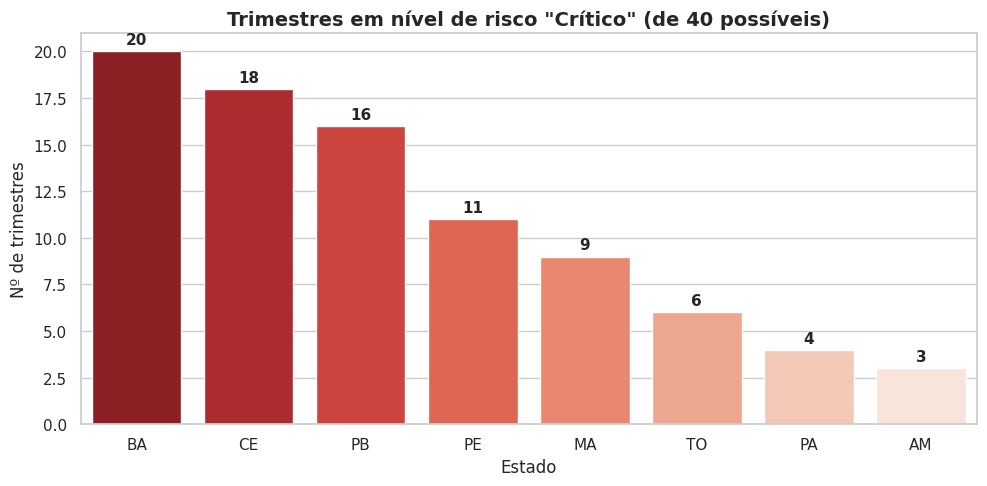

In [10]:
crit = (df.assign(critico=(df['nivel_risco'] == 'Crítico'))
          .groupby('uf').agg(taxa_media=('taxa_desemprego', 'mean'),
                             trimestres_criticos=('critico', 'sum'),
                             pct_criticos=('critico', lambda s: s.mean()*100))
          .sort_values('taxa_media', ascending=False).round(2))
display(crit.head(10))

fig, ax = plt.subplots(figsize=(10, 5))
top = crit['trimestres_criticos'].sort_values(ascending=False).head(8).reset_index()
sns.barplot(data=top, x='uf', y='trimestres_criticos', hue='uf', palette='Reds_r', legend=False, ax=ax)
for c in ax.containers:
    ax.bar_label(c, padding=3, fontweight='bold')
ax.set_title('Trimestres em nível de risco "Crítico" (de 40 possíveis)', fontsize=14, fontweight='bold')
ax.set_xlabel('Estado'); ax.set_ylabel('Nº de trimestres')
plt.tight_layout(); plt.show()

### 8.7 Dispersão: renda média × desemprego

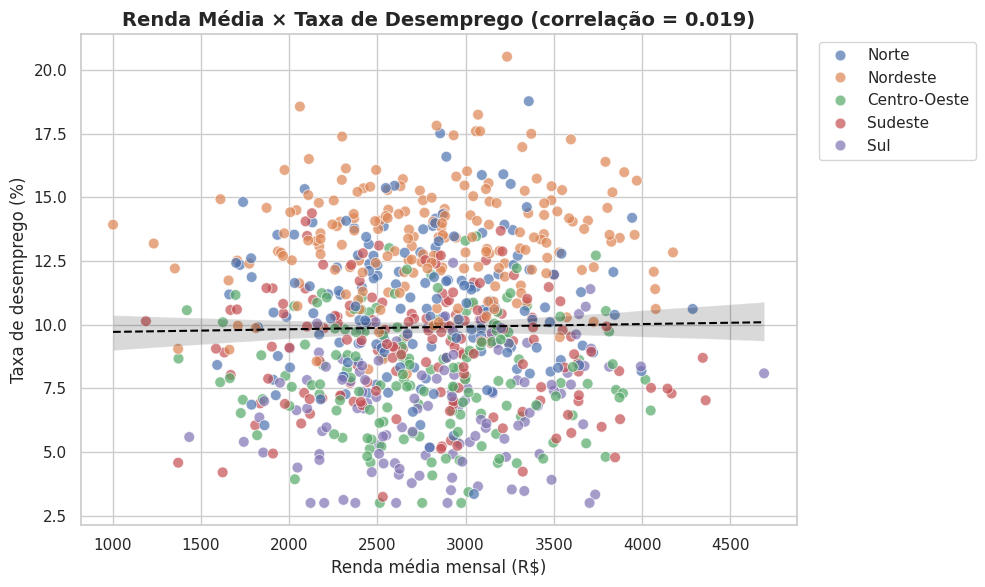

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='renda_media', y='taxa_desemprego', hue='regiao', alpha=.7, s=60, ax=ax)
sns.regplot(data=df, x='renda_media', y='taxa_desemprego', scatter=False, color='black',
            line_kws={'ls': '--', 'lw': 1.5}, ax=ax)
corr_rd = df['renda_media'].corr(df['taxa_desemprego'])
ax.set_title(f'Renda Média × Taxa de Desemprego (correlação = {corr_rd:.3f})', fontsize=14, fontweight='bold')
ax.set_xlabel('Renda média mensal (R$)'); ax.set_ylabel('Taxa de desemprego (%)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

### 8.8 Relação entre inflação e desemprego

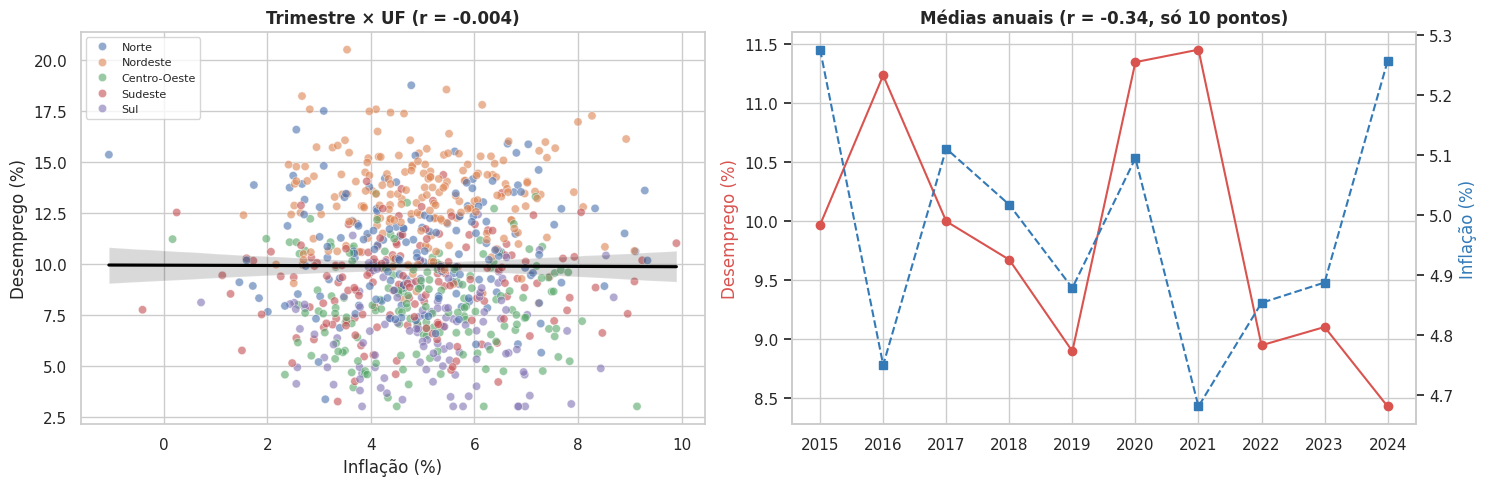

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df, x='inflacao', y='taxa_desemprego', hue='regiao', alpha=.6, ax=axes[0])
sns.regplot(data=df, x='inflacao', y='taxa_desemprego', scatter=False, color='black', ax=axes[0])
axes[0].set_title(f'Trimestre × UF (r = {df["inflacao"].corr(df["taxa_desemprego"]):.3f})', fontweight='bold')
axes[0].set_xlabel('Inflação (%)'); axes[0].set_ylabel('Desemprego (%)'); axes[0].legend(fontsize=8)

a = df.groupby('ano')[['inflacao', 'taxa_desemprego']].mean()
axes[1].plot(a.index, a['taxa_desemprego'], 'o-', color='#d9534f', label='Desemprego (%)')
axes[1].set_ylabel('Desemprego (%)', color='#d9534f')
ax2 = axes[1].twinx()
ax2.plot(a.index, a['inflacao'], 's--', color='#337ab7', label='Inflação (%)')
ax2.set_ylabel('Inflação (%)', color='#337ab7'); ax2.grid(False)
axes[1].set_title(f'Médias anuais (r = {a["inflacao"].corr(a["taxa_desemprego"]):.2f}, só 10 pontos)', fontweight='bold')
axes[1].set_xticks(a.index)
plt.tight_layout(); plt.show()

### 8.9 Renda média: por região e ao longo do tempo

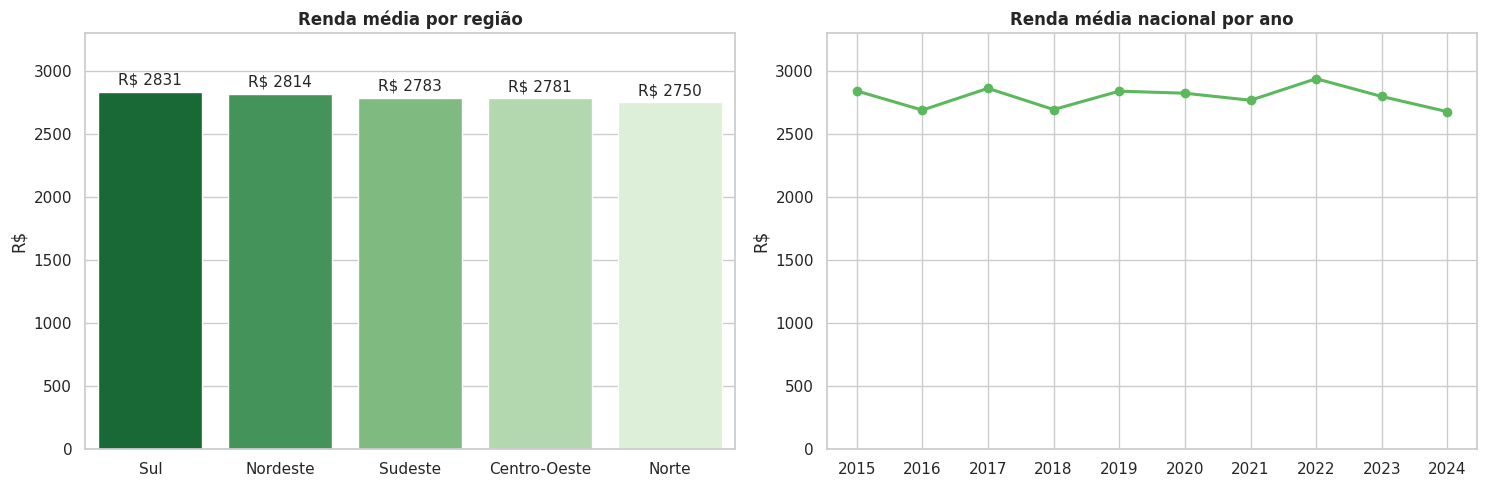

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
rr = df.groupby('regiao')['renda_media'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=rr, x='regiao', y='renda_media', hue='regiao', palette='Greens_r', legend=False, ax=axes[0])
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='R$ %.0f', padding=3)
axes[0].set_title('Renda média por região', fontweight='bold'); axes[0].set_ylim(0, 3300)
axes[0].set_xlabel(''); axes[0].set_ylabel('R$')
ra = df.groupby('ano')['renda_media'].mean()
axes[1].plot(ra.index, ra.values, 'o-', color='#5cb85c', lw=2.2)
axes[1].set_title('Renda média nacional por ano', fontweight='bold'); axes[1].set_xticks(ra.index)
axes[1].set_ylim(0, 3300)
axes[1].set_ylabel('R$')
plt.tight_layout(); plt.show()

### 8.10 Heatmaps

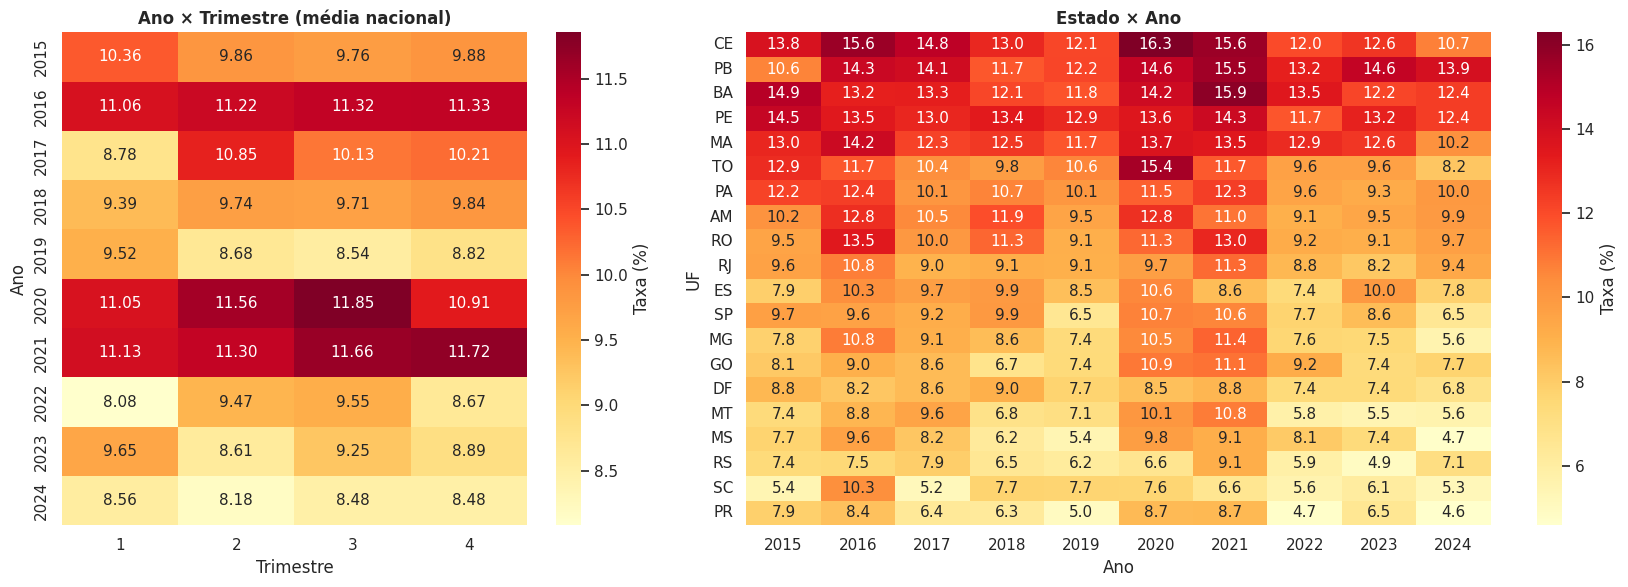

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={'width_ratios': [1, 1.6]})
piv = df.pivot_table(index='ano', columns='trimestre', values='taxa_desemprego', aggfunc='mean')
sns.heatmap(piv, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Taxa (%)'}, ax=axes[0])
axes[0].set_title('Ano × Trimestre (média nacional)', fontweight='bold')
axes[0].set_xlabel('Trimestre'); axes[0].set_ylabel('Ano')

ordem_uf = df.groupby('uf')['taxa_desemprego'].mean().sort_values(ascending=False).index
piv2 = df.pivot_table(index='uf', columns='ano', values='taxa_desemprego', aggfunc='mean').loc[ordem_uf]
sns.heatmap(piv2, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Taxa (%)'}, ax=axes[1])
axes[1].set_title('Estado × Ano', fontweight='bold'); axes[1].set_xlabel('Ano'); axes[1].set_ylabel('UF')
plt.tight_layout(); plt.show()

### 8.11 Sazonalidade (trimestre e setor)

Amplitude trimestral média: 0.27 p.p.
Desvio-padrão da taxa por setor:


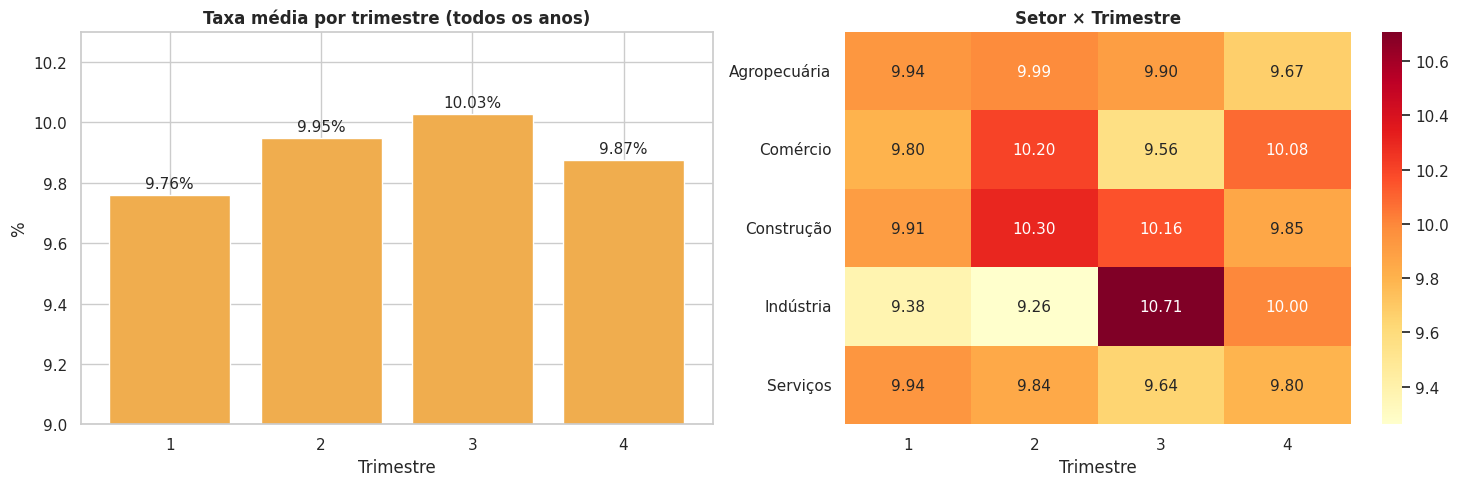

,mean,std
setor_predominante,,
Serviços,9.80,3.58
Comércio,9.92,3.20
Indústria,9.82,3.18
Construção,10.05,3.14
Agropecuária,9.87,3.10


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
s_tri = df.groupby('trimestre')['taxa_desemprego'].mean()
axes[0].bar(s_tri.index, s_tri.values, color='#f0ad4e')
axes[0].bar_label(axes[0].containers[0], fmt='%.2f%%', padding=3)
axes[0].set_ylim(9, 10.3); axes[0].set_xticks([1, 2, 3, 4])
axes[0].set_title('Taxa média por trimestre (todos os anos)', fontweight='bold')
axes[0].set_xlabel('Trimestre'); axes[0].set_ylabel('%')

piv_s = df.pivot_table(index='setor_predominante', columns='trimestre', values='taxa_desemprego', aggfunc='mean')
sns.heatmap(piv_s, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Setor × Trimestre', fontweight='bold'); axes[1].set_xlabel('Trimestre'); axes[1].set_ylabel('')
plt.tight_layout(); plt.show()

print("Amplitude trimestral média:", round(s_tri.max() - s_tri.min(), 2), "p.p.")
print("Desvio-padrão da taxa por setor:")
display(df.groupby('setor_predominante')['taxa_desemprego'].agg(['mean', 'std']).round(2).sort_values('std', ascending=False))

### 8.12 Grupos vulneráveis: nível de risco por região

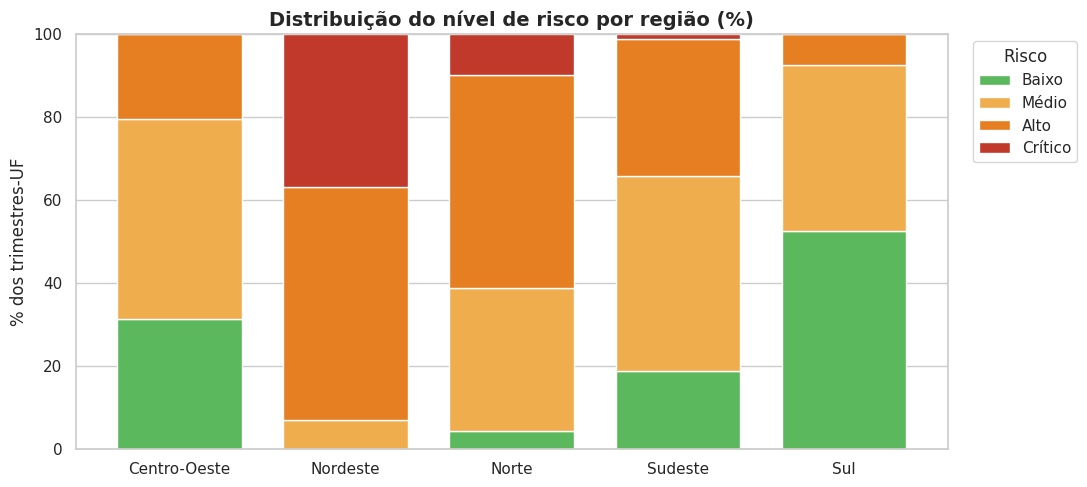

,count,mean,min,max
nivel_risco,,,,
Baixo,150,5.39,3.00,7.00
Médio,269,8.51,7.00,9.98
Alto,289,11.80,10.01,13.99
Crítico,92,15.36,14.02,20.53


In [16]:
risco = pd.crosstab(df['regiao'], df['nivel_risco'], normalize='index') * 100
cores = ['#5cb85c', '#f0ad4e', '#e67e22', '#c0392b']
ax = risco.plot(kind='bar', stacked=True, color=cores, figsize=(11, 5), width=.75)
ax.set_title('Distribuição do nível de risco por região (%)', fontsize=14, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('% dos trimestres-UF'); plt.xticks(rotation=0)
ax.legend(title='Risco', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

display(df.groupby('nivel_risco')['taxa_desemprego'].agg(['count', 'mean', 'min', 'max']).round(2))

### 8.13 Tabela dinâmica detalhada

In [17]:
tabela = df.pivot_table(index='regiao', columns='setor_predominante',
                        values=['taxa_desemprego', 'renda_media'], aggfunc='mean').round(2)
display(tabela)

display(df.pivot_table(index='regiao', columns='fase_economica', values='taxa_desemprego', aggfunc='mean')
          [['Recessão 2015-16', 'Recuperação 2017-19', 'Pandemia 2020-21', 'Retomada 2022-24']].round(2))

renda_media                                        taxa_desemprego                                       
setor_predominante Agropecuária Comércio Construção Indústria Serviços    Agropecuária Comércio Construção Indústria Serviços
regiao                                                                                                                       
Centro-Oeste            2756.71  2731.40    2744.13   2750.64  2950.84            8.02     7.99       8.38      7.61     8.15
Nordeste                2982.48  2812.00    2866.70   2763.70  2644.95           13.37    13.76      13.18     13.13    12.97
Norte                   2698.58  2647.29    2792.62   2799.20  2767.90           10.51    10.63      10.75     11.02    10.94
Sudeste                 2887.89  2802.34    2680.07   2734.85  2853.41            9.35     9.32       9.07      8.32     9.20
Sul                     2747.10  2858.83    2741.65   2886.76  2934.60            7.07     6.84       6.47      7.45     6.17

fase_economica,Recessão 2015-16,Recuperação 2017-19,Pandemia 2020-21,Retomada 2022-24
regiao,,,,
Centro-Oeste,8.46,7.63,9.89,6.91
Nordeste,13.78,12.72,14.72,12.53
Norte,11.89,10.33,12.37,9.39
Sudeste,9.56,8.84,10.42,7.91
Sul,7.82,6.53,7.89,5.63


## 9. Identificação de períodos de crise

Critério objetivo: um ano é considerado **crise** quando a taxa média nacional supera *média do período + 1 desvio-padrão*.

Limite de crise: 11.01%  (média 9.90% + 1 desvio-padrão 1.11)


,taxa_%,var_vs_ano_anterior_pp,crise
ano,,,
2015,9.97,NaN,False
2016,11.23,1.27,True
2017,10.00,-1.24,False
2018,9.67,-0.33,False
2019,8.89,-0.78,False
2020,11.35,2.45,True
2021,11.45,0.11,True
2022,8.94,-2.51,False
2023,9.10,0.15,False


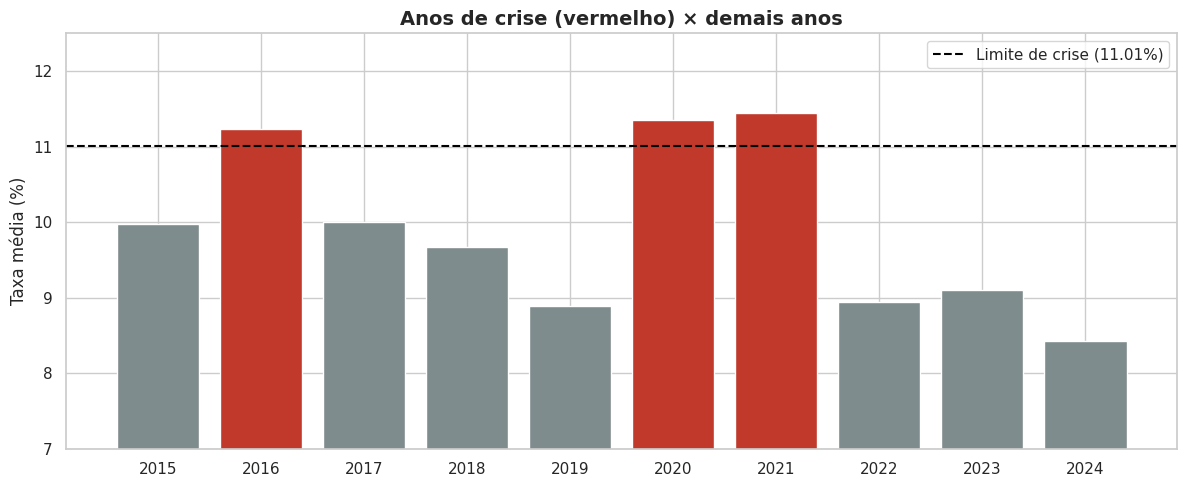

In [18]:
anual = df.groupby('ano')['taxa_desemprego'].mean()
limite = anual.mean() + anual.std()
crise = pd.DataFrame({'taxa_%': anual.round(2),
                      'var_vs_ano_anterior_pp': anual.diff().round(2),
                      'crise': anual > limite})
print(f"Limite de crise: {limite:.2f}%  (média {anual.mean():.2f}% + 1 desvio-padrão {anual.std():.2f})")
display(crise)

fig, ax = plt.subplots(figsize=(12, 5))
cores = ['#c0392b' if c else '#7f8c8d' for c in crise['crise']]
ax.bar(crise.index, crise['taxa_%'], color=cores)
ax.axhline(limite, color='black', ls='--', label=f'Limite de crise ({limite:.2f}%)')
ax.set_ylim(7, 12.5); ax.set_xticks(crise.index); ax.legend()
ax.set_title('Anos de crise (vermelho) × demais anos', fontsize=14, fontweight='bold')
ax.set_ylabel('Taxa média (%)')
plt.tight_layout(); plt.show()

## 10. Interpretação dos resultados (perguntas orientadoras)

**1. Quais regiões apresentam maior desemprego?**
O **Nordeste** lidera com 13,28% de média, seguido do **Norte** (10,77%). Sudeste (9,02%), Centro-Oeste (8,03%) e **Sul** (6,79%) ficam abaixo da média nacional (9,90%). O Nordeste tem quase o **dobro** da taxa do Sul (6,5 p.p. de diferença).

**2. Quais estados apresentam menores taxas?**
Os três estados do Sul: **PR (6,71%), SC (6,75%) e RS (6,92%)**, seguidos de MS (7,63%) e MT (7,74%). No outro extremo: CE (13,65%), PB (13,47%), BA (13,35%), PE (13,24%) e MA (12,67%), todos nordestinos. Os 5 estados com maior desemprego do país estão na mesma região.

**3. Existem períodos de crise mais evidentes?**
Sim, dois. A **recessão de 2015-16** (pico de 11,23% em 2016) e a **pandemia de 2020-21** (11,35% e 11,45%), esta com o maior salto anual da série (+2,45 p.p. de 2019 para 2020). O pior trimestre foi **2020-T3 (11,85%)**. Pelo critério objetivo de média + 1 desvio-padrão (limite de 11,01%), **2016, 2020 e 2021 são classificados como anos de crise**.

**4. O desemprego aumentou ou diminuiu?**
**Diminuiu**: de 9,97% (2015) para 8,43% (2024), −1,54 p.p. A queda não foi linear: o país passou por recessão, recuperação (2017-19), choque da pandemia e retomada forte em 2022 (−2,51 p.p. em um ano). 2024 é o **menor valor de toda a série**.

**5. Há diferenças relevantes entre regiões?**
Sim, e são **persistentes**: a ordem das regiões praticamente não muda ao longo dos anos (Nordeste > Norte > Sudeste > Centro-Oeste > Sul). Todas reagem às crises na mesma direção, e o Nordeste chegou a 15,0% em 2021. A diferença regional é estrutural, não passageira.

**6. Há sazonalidade em determinados setores?**
**Não há evidência forte.** A amplitude entre trimestres é de apenas ~0,3 p.p. (T1 9,76% a T3 10,03%). Entre setores, as médias são quase idênticas (9,8% a 10,05%). Alguns cruzamentos setor × trimestre destoam (Indústria em T3: 10,71%; em T1/T2: ~9,3%), mas a diferença é pequena e, em dados simulados, pode ser ruído. *A versão anterior do notebook afirmava que Construção Civil era a mais volátil; isso não se confirma: o maior desvio-padrão é de Serviços (3,58), e Construção tem 3,14.*

**7. Quais grupos parecem mais vulneráveis?**
O **Nordeste**: 37% dos seus trimestres-UF estão em nível **Crítico** e nenhum em nível Baixo. As UFs com mais trimestres críticos são **BA (20), CE (18), PB (16), PE (11) e MA (9)**. O Norte aparece em seguida (10% crítico). Sul e Centro-Oeste nunca atingiram o nível Crítico.

**Relações econômicas**
- **Renda × desemprego:** correlação ≈ **0,02**, praticamente nula. Nos dados, quem tem renda média maior **não** tem menos desemprego, e a renda é quase igual entre regiões (R$ 2.750 a R$ 2.831). Em dados reais, esperaríamos desigualdade de renda entre regiões, então esse é um limite da simulação.
- **Inflação × desemprego:** correlação ≈ **0,00** entre trimestres-UF. Nas médias anuais aparece r ≈ −0,34, mas com só 10 pontos não é estatisticamente confiável. Não há sinal claro de curva de Phillips.
- **Vagas formais:** a correlação com o desemprego também é praticamente nula (−0,02), ou seja, os dados de vagas não explicam a taxa.

## 11. Conclusão executiva

1. **O desemprego caiu na década**: de 9,97% (2015) para 8,43% (2024), o menor patamar da série, após dois choques (recessão 2015-16 e pandemia 2020-21).
2. **A desigualdade regional é o principal achado**: o Nordeste tem 13,28% contra 6,79% do Sul e concentra os 5 estados mais afetados e quase todos os trimestres em nível crítico. Essa diferença persiste em todos os anos.
3. **As crises afetaram todas as regiões ao mesmo tempo**, mas não alteraram o ranking regional: o Nordeste já partia de patamar mais alto e chegou a 15% em 2021.
4. **Renda e inflação não explicam o desemprego neste dataset** (correlações ≈ 0). Isso é uma limitação dos dados simulados, e a análise com dados reais (PNAD Contínua/IBGE) provavelmente mostraria relações mais fortes.
5. **Recomendação:** políticas de emprego e qualificação devem priorizar **BA, CE, PB, PE e MA**, e o monitoramento deve usar o nível de risco como alerta antecipado.

**Limitações:** dados simulados; apenas 20 dos 27 estados; sem recortes por sexo, idade ou escolaridade (que permitiriam estudar grupos vulneráveis de forma mais direta); setor predominante varia aleatoriamente ao longo do tempo em cada estado.

**Próximos passos:** dashboard interativo em Streamlit (`app.py`), persistência em SQLite e comparação com dados oficiais do IBGE.